obtaining unique combination of CIK - periodofreport - reporting_day_lag


In [2]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path(r"C:\Users\tyiho\DSE3101 Project\dse3101investmentproject\Datasets\13F_filtered_and_mapped_files")

In [9]:
large_df = []

for file in DATA_DIR.glob("*.parquet"):
    if file.name in [   "cusip_ticker_map.parquet"]:
        continue
    df = pd.read_parquet(file, columns=[
        "CIK",
        "PERIODOFREPORT",
        "FILING_DATE",
        "SUBMISSIONTYPE"
    ])

    # remove duplicate rows caused by holdings
    df = df.drop_duplicates(
        subset=["CIK", "PERIODOFREPORT", "FILING_DATE", "SUBMISSIONTYPE"]
    )

    # get FIRST filing per manager per quarter
    first_filings = (
        df.sort_values("FILING_DATE")
          .groupby(["CIK", "PERIODOFREPORT"], as_index=False)
          .first()
    )

    # compute reporting lag
    first_filings["reporting_days_lag"] = (
        first_filings["FILING_DATE"] - first_filings["PERIODOFREPORT"]
    ).dt.days

    large_df.append(first_filings)

# combine all files
large_large_df = pd.concat(large_df, ignore_index=True)

In [10]:
lags_df = large_large_df[["reporting_days_lag"]].copy()

print("\nPercentiles:")
print(lags_df["reporting_days_lag"].quantile([
    0.5,   # median
    0.75,
    0.9,
    0.92,
    0.95,
    0.96,
    0.97,
    0.98,
    0.99
]))



Percentiles:
0.50    41.0
0.75    45.0
0.90    45.0
0.92    46.0
0.95    47.0
0.96    47.0
0.97    47.0
0.98    48.0
0.99    51.0
Name: reporting_days_lag, dtype: float64


hence, if we choose 47 lag days after the quarter end as our cut off value, we can capture 97% of filings

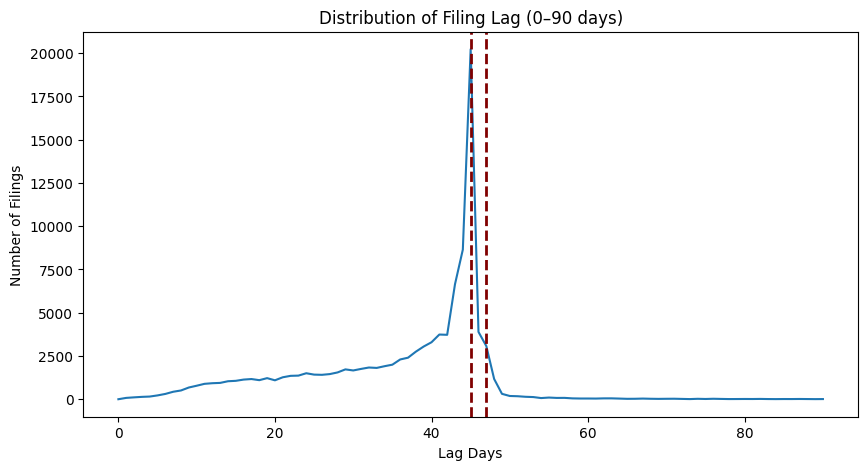

In [57]:
lag_counts = lags_df["reporting_days_lag"].value_counts().sort_index().loc[0:90]

plt.figure(figsize=(10,5))
plt.plot(lag_counts.index, lag_counts.values)

plt.xlabel("Lag Days")
plt.ylabel("Number of Filings")
plt.title("Distribution of Filing Lag (0–90 days)")
plt.axvline(x=45, linestyle="--", linewidth=2, color="maroon", label="SEC Deadline (45 days)")
plt.axvline(x=47, linestyle="--", linewidth=2, color="maroon", label="Late Filing Threshold (47 days)")

plt.show()

In [41]:
late_filings = large_large_df[large_large_df["reporting_days_lag"] > 47]

late_by_manager = (
    all_late_fillings_df.groupby(["CIK","FILINGMANAGER_NAME"])
    .size()
    .sort_values(ascending=False)
)

In [42]:
print(late_by_manager.head(50))

CIK         FILINGMANAGER_NAME                                 
0001584686  Kentucky Retirement Systems Insurance Trust Fund       19
0001537783  Kentucky Retirement Systems                            19
0001105863  AUXIER ASSET MANAGEMENT                                18
0001540569  EP Wealth Advisors, LLC                                18
0001007280  PUBLIC EMPLOYEES RETIREMENT SYSTEM OF OHIO             14
0000931097  CCM INVESTMENT ADVISERS LLC                            14
0000918504  BIRMINGHAM CAPITAL MANAGEMENT CO INC/AL                14
0001353110  Aldebaran Financial Inc.                               14
0000714142  TEACHERS RETIREMENT SYSTEM OF THE STATE OF KENTUCKY    14
0001224962  PERCEPTIVE ADVISORS LLC                                13
0001106832  CASTLEARK MANAGEMENT LLC                               13
0001698926  Adalta Capital Management LLC                          13
0001575239  Perigon Wealth Management, LLC                         13
0001633037  Rehmann Capita

In [ ]:
late_by_quarter = (
    all_late_fillings_df.groupby("PERIODOFREPORT")
    .size()
)

print(late_by_quarter)

PERIODOFREPORT
2013-06-30     44
2013-09-30     30
2013-12-31     72
2014-03-31     33
2014-06-30     44
2014-09-30     63
2014-12-31    344
2015-03-31     52
2015-06-30     63
2015-09-30     49
2015-12-31     59
2016-03-31     39
2016-06-30     43
2016-09-30     35
2016-12-31     61
2017-03-31     38
2017-06-30     43
2017-09-30     35
2017-12-31     51
2018-03-31     42
2018-06-30     40
2018-09-30     39
2018-12-31     54
2019-03-31     34
2019-06-30     42
2019-09-30     44
2019-12-31     61
2020-03-31     69
2020-06-30     98
2020-09-30     66
2020-12-31     94
2021-03-31     77
2021-06-30     66
2021-09-30     39
2021-12-31     38
2022-03-31     52
2022-06-30     45
2022-09-30     31
2022-12-31     43
2023-03-31     34
2023-06-30     38
2023-09-30     51
2023-12-31     38
2024-03-31     31
2024-06-30     28
2024-09-30     43
2024-12-31     68
2025-03-31     40
2025-06-30     31
2025-09-30     77
2025-12-31    496
dtype: int64


In [3]:
#testing to see what columns are in the files

DATA_DIR = Path(r"C:\Users\tyiho\DSE3101 Project\dse3101investmentproject\Datasets\13F_filtered_and_mapped_files")

file = next(DATA_DIR.glob("*.parquet"))  # get one file
df = pd.read_parquet(file)

print(df.columns)

Index(['CIK', 'FILINGMANAGER_NAME', 'PERIODOFREPORT', 'FILING_DATE',
       'SUBMISSIONTYPE', 'TABLEVALUETOTAL', 'TABLEENTRYTOTAL',
       'ISCONFIDENTIALOMITTED', 'NAMEOFISSUER', 'CUSIP', 'VALUE', 'SSHPRNAMT',
       'weight', 'ticker', 'security_type', 'name', 'exchCode',
       'equity_portfolio_total', 'equity_weight'],
      dtype='object')


In [ ]:
results = []

for file in DATA_DIR.glob("*.parquet"):

    if file.name in ["cusip_ticker_map.parquet",
                     "2013q2_form13f_clean.parquet_final.parquet"]:
        continue

    df = pd.read_parquet(file, columns=["PERIODOFREPORT"])

    counts = df["PERIODOFREPORT"].value_counts()

    for period, count in counts.items():
        results.append({
            "file": file.name,
            "PERIODOFREPORT": period,
            "count": count
        })

results_df = pd.DataFrame(results).sort_values(["file","PERIODOFREPORT"])

print(results_df)


   PERIODOFREPORT   count
0      2013-06-30  126619
1      2013-09-30  133728
2      2013-12-31  143783
3      2014-03-31  153366
4      2014-06-30  158279
5      2014-09-30  160362
6      2014-12-31  173770
7      2015-03-31  176498
8      2015-06-30  186608
9      2015-09-30  192263
10     2015-12-31  195274
11     2016-03-31  206922
12     2016-06-30  212316
13     2016-09-30  217046
14     2016-12-31  232244
15     2017-03-31  259815
16     2017-06-30  268130
17     2017-09-30  271849
18     2017-12-31  307203
19     2018-03-31  319327
20     2018-06-30  334106
21     2018-09-30  343430
22     2018-12-31  337769
23     2019-03-31  357521
24     2019-06-30  366308
25     2019-09-30  363067
26     2019-12-31  355237
27     2020-03-31  324288
28     2020-06-30  343421
29     2020-09-30  349146
30     2020-12-31  365230
31     2021-03-31  376077
32     2021-06-30  383586
33     2021-09-30  387245
34     2021-12-31  364768
35     2022-03-31  396513
36     2022-06-30  392814
37     2022-

In [1]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path(r"C:\Users\tyiho\DSE3101 Project\dse3101investmentproject\Datasets\13F_filtered_and_mapped_files")

for file in DATA_DIR.glob("*.parquet"):

    if file.name in ["cusip_ticker_map.parquet",
                     "2013q2_form13f_clean.parquet_final.parquet"]:
        continue

    print(f"\nChecking file: {file.name}")

    df = pd.read_parquet(file, columns=[
        "CIK",
        "PERIODOFREPORT",
        "SUBMISSIONTYPE",
        "FILING_DATE"
    ])
    
    # find managers who have both HR and HR/A
    test = (
        df.groupby(["CIK","PERIODOFREPORT"])["SUBMISSIONTYPE"]
          .nunique()
    )
    
    
    problematic = test[test > 1]
    
    if len(problematic) == 0:
        print("No amendments detected")
        continue

    print("Managers with both HR and HR/A:")

    # show row counts per filing
    details = (
        df.groupby(
            ["CIK","PERIODOFREPORT","FILING_DATE","SUBMISSIONTYPE"]
        ).size()
    )

    print("\nRow counts per filing:")
    print(details.loc[problematic.index])


Checking file: 01dec2024-28feb2025_form13f_clean.parquet_final.parquet
No amendments detected

Checking file: 01dec2025-28feb2026_form13f_clean.parquet_final.parquet
No amendments detected

Checking file: 01jan2024-29feb2024_form13f_clean.parquet_final.parquet
No amendments detected

Checking file: 01jun2024-31aug2024_form13f_clean.parquet_final.parquet
No amendments detected

Checking file: 01jun2025-31aug2025_form13f_clean.parquet_final.parquet
No amendments detected

Checking file: 01mar2024-31may2024_form13f_clean.parquet_final.parquet
No amendments detected

Checking file: 01mar2025-31may2025_form13f_clean.parquet_final.parquet
No amendments detected

Checking file: 01sep2024-30nov2024_form13f_clean.parquet_final.parquet
No amendments detected

Checking file: 01sep2025-30nov2025_form13f_clean.parquet_final.parquet
No amendments detected

Checking file: 2013q3_form13f_clean.parquet_final.parquet
No amendments detected

Checking file: 2013q4_form13f_clean.parquet_final.parquet
No a

In [2]:

file2 = DATA_DIR / "2017q2_form13f_clean.parquet_final.parquet"
# df = pd.read_parquet(file2, columns=["SUBMISSIONTYPE"])

# print(df["SUBMISSIONTYPE"].unique())

df = pd.read_parquet(file2, columns=["SUBMISSIONTYPE"])

print(df["SUBMISSIONTYPE"].value_counts())

df = pd.read_parquet(file2, columns=[
    "CIK",
    "PERIODOFREPORT",
    "SUBMISSIONTYPE"
])

test = (
    df.groupby(["CIK","PERIODOFREPORT"])["SUBMISSIONTYPE"]
      .nunique()
)

print(test.describe())

SUBMISSIONTYPE
13F-HR      258489
13F-HR/A      2293
Name: count, dtype: int64
count    1808.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: SUBMISSIONTYPE, dtype: float64


In [3]:
#checking if amendments are duplicates of original filings
for file in DATA_DIR.glob("*.parquet"):

    if file.name in ["cusip_ticker_map.parquet",
                     "2013q2_form13f_clean.parquet_final.parquet"]:
        continue
    
    print(f"\nChecking file: {file.name}")
    df = pd.read_parquet(file, columns=[
        "CIK",
        "PERIODOFREPORT",
        "SUBMISSIONTYPE"
    ])

    test = (
        df.groupby(["CIK","PERIODOFREPORT"])["SUBMISSIONTYPE"]
        .nunique()
    )

    print(test.describe())
        


Checking file: 01dec2024-28feb2025_form13f_clean.parquet_final.parquet
count    2339.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: SUBMISSIONTYPE, dtype: float64

Checking file: 01dec2025-28feb2026_form13f_clean.parquet_final.parquet
count    2184.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: SUBMISSIONTYPE, dtype: float64

Checking file: 01jan2024-29feb2024_form13f_clean.parquet_final.parquet
count    2453.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: SUBMISSIONTYPE, dtype: float64

Checking file: 01jun2024-31aug2024_form13f_clean.parquet_final.parquet
count    2433.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: SUBMISSIONTYPE, dtype: float64

Checking file: 01jun2025-31aug2025_form13f_clean.pa

In [ ]:
results = []

for file in DATA_DIR.glob("*.parquet"):

    if file.name == "cusip_ticker_map.parquet":
        continue

    print(f"Checking file: {file.name}")

    df = pd.read_parquet(file)

    # -------------------------
    # FILTER COMMON STOCK
    # -------------------------
    common_stock = df[df["security_type"] == "Common Stock"]

    # -------------------------
    # GROUP BY INSTITUTION + QUARTER
    # -------------------------
    summary = (
        common_stock
        .groupby(["CIK", "PERIODOFREPORT"])
        .agg(
            num_unique_common_stocks=("CUSIP", "nunique"),
            avg_value_common_stocks=("VALUE", "mean")
        )
        .reset_index()
    )

    results.append(summary)

# Combine all quarters
results_df = pd.concat(results, ignore_index=True)




Checking file: 01dec2024-28feb2025_form13f_clean.parquet_final.parquet
Checking file: 01dec2025-28feb2026_form13f_clean.parquet_final.parquet
Checking file: 01jan2024-29feb2024_form13f_clean.parquet_final.parquet
Checking file: 01jun2024-31aug2024_form13f_clean.parquet_final.parquet
Checking file: 01jun2025-31aug2025_form13f_clean.parquet_final.parquet
Checking file: 01mar2024-31may2024_form13f_clean.parquet_final.parquet
Checking file: 01mar2025-31may2025_form13f_clean.parquet_final.parquet
Checking file: 01sep2024-30nov2024_form13f_clean.parquet_final.parquet
Checking file: 01sep2025-30nov2025_form13f_clean.parquet_final.parquet
Checking file: 2013q2_form13f_clean.parquet_final.parquet
Checking file: 2013q3_form13f_clean.parquet_final.parquet
Checking file: 2013q4_form13f_clean.parquet_final.parquet
Checking file: 2014q1_form13f_clean.parquet_final.parquet
Checking file: 2014q2_form13f_clean.parquet_final.parquet
Checking file: 2014q3_form13f_clean.parquet_final.parquet
Checking file

,CIK,PERIODOFREPORT,num_unique_common_stocks,avg_value_common_stocks
0,0000002230,2024-12-31,84,2.896715e+07
1,0000005272,2024-12-31,2,1.905977e+09
2,0000007195,2024-12-31,98,1.395347e+06
3,0000009015,2024-12-31,8,1.783038e+07
4,0000009631,2024-12-31,592,6.019613e+07
...,...,...,...,...
105283,0001776290,2023-09-30,97,1.709985e+06
105284,0001776296,2023-09-30,53,2.914177e+06
105285,0001776792,2023-09-30,180,1.177866e+06
105286,0001778185,2023-09-30,55,1.229402e+06


In [7]:
institution_summary = (
    results_df
    .groupby("CIK")
    .agg(
        avg_unique_common_stocks=("num_unique_common_stocks", "mean"),
        avg_value_common_stocks=("avg_value_common_stocks", "mean"),
        num_quarters=("PERIODOFREPORT", "nunique")
    )
    .reset_index()
)

institution_summary

,CIK,avg_unique_common_stocks,avg_value_common_stocks,num_quarters
0,0000002230,73.333333,2.266663e+07,51
1,0000005272,1850.803922,2.640741e+09,51
2,0000007195,65.647059,3.110664e+06,51
3,0000009015,312.803922,7.716275e+06,51
4,0000009631,435.156863,5.207678e+07,51
...,...,...,...,...
2475,0001776290,78.642857,1.592762e+06,28
2476,0001776296,53.259259,2.496075e+07,27
2477,0001776792,211.821429,1.145626e+06,28
2478,0001778185,45.125000,1.106102e+06,24


In [8]:
institution_summary.to_csv("institution_summary.csv", index=False)

In [5]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path(r"C:\Users\tyiho\DSE3101 Project\dse3101investmentproject\Datasets\13F_filtered_and_mapped_files")

results_common = []
results_us = []
results_common_us = []

for file in DATA_DIR.glob("*.parquet"):

    if file.name in ["cusip_ticker_map.parquet", "01jun2025-31aug2025_form13f_clean.parquet_final.parquet"]:
        continue

    print(f"Checking file: {file.name}")

    df = pd.read_parquet(file)

    # -------------------------
    # DEFINE FILTERS
    # -------------------------

    common_stock = df[df["security_type"] == "Common Stock"]

    us_stock = df[df["exchCode"] == "US"]

    common_us_stock = df[
        (df["security_type"] == "Common Stock") &
        (df["exchCode"] == "US")
    ]

    # -------------------------
    # FUNCTION TO COMPUTE SUMMARY
    # -------------------------

    def compute_summary(filtered_df, label):
        return (
            filtered_df
            .groupby(["CIK", "PERIODOFREPORT"])
            .agg(
                num_unique_stocks=("CUSIP", "nunique"),
                avg_value=("VALUE", "mean")
            )
            .reset_index()
        )

    # -------------------------
    # APPLY
    # -------------------------

    results_common.append(compute_summary(common_stock, "common"))
    results_us.append(compute_summary(us_stock, "us"))
    results_common_us.append(compute_summary(common_us_stock, "common_us"))

# -------------------------
# CONCAT ALL FILES
# -------------------------

df_common = pd.concat(results_common, ignore_index=True)
df_us = pd.concat(results_us, ignore_index=True)
df_common_us = pd.concat(results_common_us, ignore_index=True)

# -------------------------
# AGGREGATE TO INSTITUTION LEVEL
# -------------------------

def institution_level(df):
    return (
        df.groupby("CIK")
        .agg(
            avg_unique_stocks=("num_unique_stocks", "mean"),
            avg_value=("avg_value", "mean"),
            num_quarters=("PERIODOFREPORT", "nunique")
        )
        .reset_index()
    )

inst_common = institution_level(df_common)
inst_us = institution_level(df_us)
inst_common_us = institution_level(df_common_us)

# -------------------------
# SAVE TO CSV
# -------------------------

inst_common.to_csv("common_stock_summary.csv", index=False)
inst_us.to_csv("us_stock_summary.csv", index=False)
inst_common_us.to_csv("common_us_stock_summary.csv", index=False)

print("Saved 3 CSV files successfully.")

Checking file: 01dec2024-28feb2025_form13f_clean.parquet_final.parquet
Checking file: 01dec2025-28feb2026_form13f_clean.parquet_final.parquet
Checking file: 01jan2024-29feb2024_form13f_clean.parquet_final.parquet
Checking file: 01jun2024-31aug2024_form13f_clean.parquet_final.parquet
Checking file: 01mar2024-31may2024_form13f_clean.parquet_final.parquet
Checking file: 01mar2025-31may2025_form13f_clean.parquet_final.parquet
Checking file: 01sep2024-30nov2024_form13f_clean.parquet_final.parquet
Checking file: 01sep2025-30nov2025_form13f_clean.parquet_final.parquet
Checking file: 2013q2_form13f_clean.parquet_final.parquet
Checking file: 2013q3_form13f_clean.parquet_final.parquet
Checking file: 2013q4_form13f_clean.parquet_final.parquet
Checking file: 2014q1_form13f_clean.parquet_final.parquet
Checking file: 2014q2_form13f_clean.parquet_final.parquet
Checking file: 2014q3_form13f_clean.parquet_final.parquet
Checking file: 2014q4_form13f_clean.parquet_final.parquet
Checking file: 2015q1_form